In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
all_ecms = {}
dime_codes = {"Rhodoferax": ["mEmC_13", "mEmC_24", "mEmC_5", "mEmC_6", "mE_1"],
              "Geobacter": ["mEmC_12", "mEmC_34", "mEmC_56", "mE_1"]}

for model, dime_numbers in dime_codes.items():
    for code in dime_numbers:
        ecms = pd.read_csv(f"results/{model}_{code}_full_conversions_ex_compress.csv")

        typ = code.split("_")[0]
        n = code.split("_")[1]
        for digit in n:
            dime_id = f"{typ}_{digit}"
            if not all_ecms.get(dime_id):
                all_ecms[dime_id] = {}
            all_ecms[dime_id][model] = ecms

In [3]:
bm_rxns = {"Geobacter": "objective", "Rhodoferax": "objective"}
c_sources = {
    "mEmC_1": {"Geobacter": "M_mal__45__L_e", "Rhodoferax": "M_fum_e"},
    "mEmC_2": {"Geobacter": "M_mal__45__L_e", "Rhodoferax": "M_cit_e"},
    "mEmC_3": {"Geobacter": "M_mal__45__L_e", "Rhodoferax": "M_fum_e"},
    "mEmC_4": {"Geobacter": "M_mal__45__L_e", "Rhodoferax": "M_cit_e"},
    "mEmC_5": {"Geobacter": "M_cit_e", "Rhodoferax": "M_mal__45__L_e"},
    "mEmC_6": {"Geobacter": "M_cit_e", "Rhodoferax": "M_mal__45__L_e"},
    "mE_1": {"Geobacter": "M_mal__45__L_e", "Rhodoferax": "M_ac_e"},

}

**** Pattern mEmC_1 *****
Rhodoferax: 385 ECMs
   200 growing ECMs
Geobacter: 1310 ECMs
   638 growing ECMs


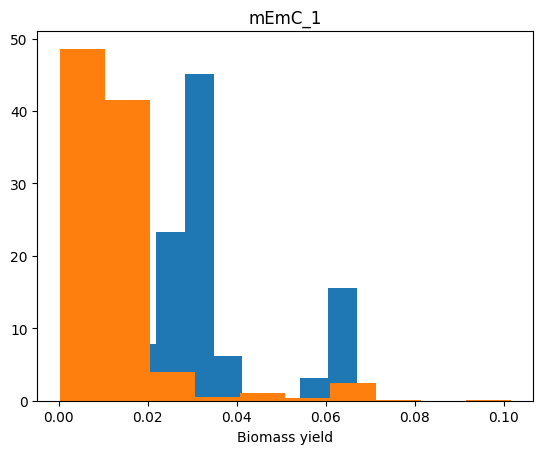

**** Pattern mEmC_3 *****
Rhodoferax: 385 ECMs
   200 growing ECMs
Geobacter: 798 ECMs
   304 growing ECMs


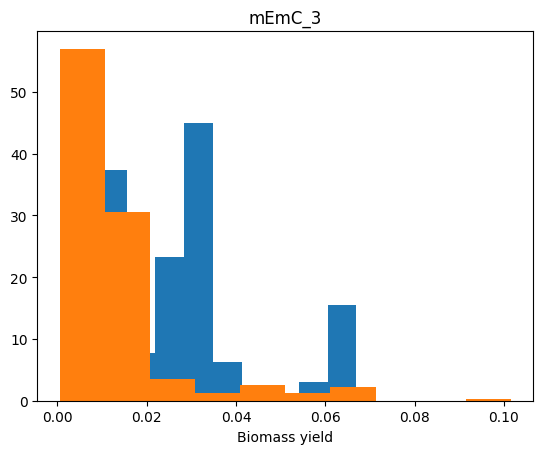

**** Pattern mEmC_2 *****
Rhodoferax: 883 ECMs
   382 growing ECMs
Geobacter: 1310 ECMs
   638 growing ECMs


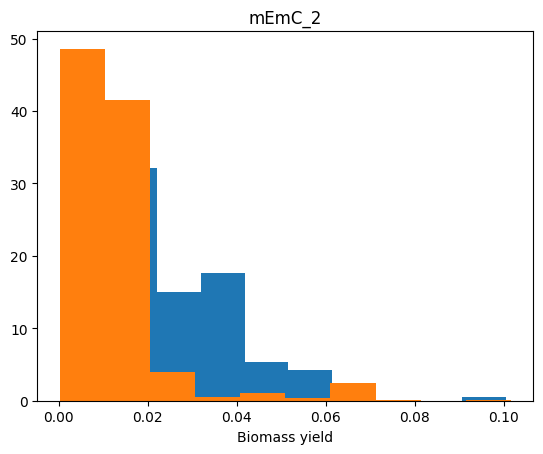

**** Pattern mEmC_4 *****
Rhodoferax: 883 ECMs
   382 growing ECMs
Geobacter: 798 ECMs
   304 growing ECMs


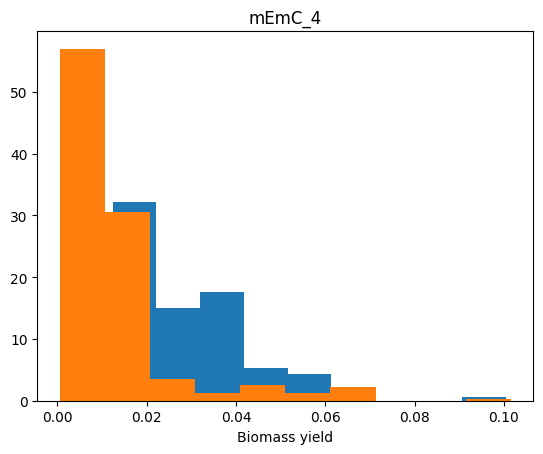

**** Pattern mEmC_5 *****
Rhodoferax: 154 ECMs
   68 growing ECMs
Geobacter: 698 ECMs
   264 growing ECMs


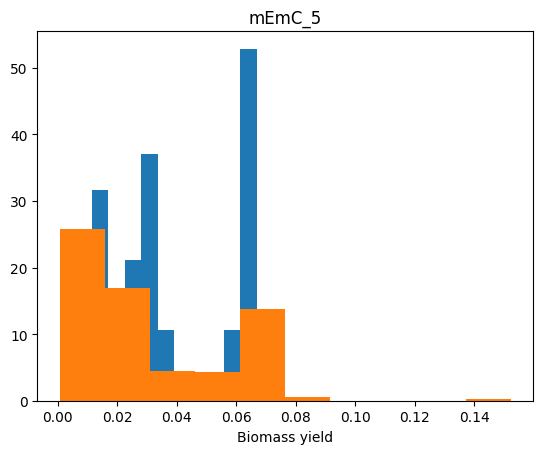

**** Pattern mEmC_6 *****
Rhodoferax: 102 ECMs
   44 growing ECMs
Geobacter: 698 ECMs
   264 growing ECMs


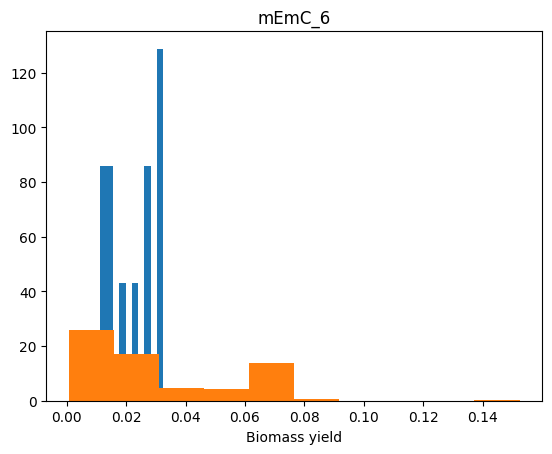

**** Pattern mE_1 *****
Rhodoferax: 78 ECMs
   29 growing ECMs
Geobacter: 798 ECMs
   304 growing ECMs


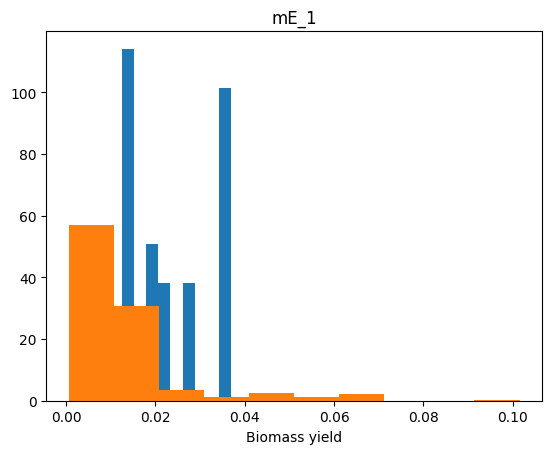

In [4]:
growing_ecms = {}
for dime, ecms_dime in all_ecms.items():
    print(f"**** Pattern {dime} *****")
    growing_ecms[dime] = {}
    for model, ecms in ecms_dime.items():
        print(f"{model}: {len(ecms)} ECMs")
        growing = ecms[ecms[bm_rxns[model]] > 0]
        growing = growing.div(growing[bm_rxns[model]], axis=0)

        print(f"   {len(growing)} growing ECMs")
        yields = growing[bm_rxns[model]]/growing[c_sources[dime][model]]

        growing=round(growing,5).drop_duplicates()
        # print(f"{len(growing)} ECMs (rounded)")

        growing_ecms[dime][model] = growing

        plt.hist(abs(yields), density = True)
        plt.xlabel("Biomass yield")
        plt.title(f"{dime}")
    plt.show()

In [5]:
all_dimes = {"Rhodoferax": {
            "mEmC_1": {"uptakes": ["M_fe2_e", "M_fum_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_2": {"uptakes": ["M_fe2_e", "M_cit_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_3": {"uptakes": ["M_fe2_e", "M_fum_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_4": {"uptakes": ["M_fe2_e", "M_cit_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_5": {"uptakes": ["M_fe2_e", "M_mal__45__L_e"],
                "secretion": []},
            "mEmC_6": {"uptakes": ["M_fe2_e", "M_mal__45__L_e",                                 "M_co2_e"],
                "secretion": []},
            "mE_1": {"uptakes": ["M_ac_e"],
                    "secretion": []}
},
        "Geobacter": {
            "mEmC_1": {"uptakes": ["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_2": {"uptakes": ["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_3": {"uptakes": ["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_4": {"uptakes": ["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_5": {"uptakes": ["M_cit_e"],
                "secretion": ["M_mal__45__L_e", "M_fe2_e"]},
            "mEmC_6": {"uptakes": ["M_cit_e"],
                "secretion": ["M_mal__45__L_e", "M_fe2_e", "M_co2_e"]},
            "mE_1": {"uptakes": ["M_mal__45__L_e"],
                    "secretion": ["M_ac_e"]}
        }}

sec_only = ["M_h2_e"]
off = [] # ["M_ac_e", "M_glu__45__L_e", "M_hom__45__L_e", "M_glyclt_e",
     # "M_pro__45__L_e", "M_pyr_e", "M_ac_e"]
#,      "M_pyr_e", "M_succ_e"]

In [6]:
filtered_ecms = {}
for model, dimes in all_dimes.items():
    print(model)
    for dime_number, dime in dimes.items():
        if not filtered_ecms.get(dime_number):
            filtered_ecms[dime_number] = {}
        ecms = growing_ecms[dime_number][model]

        cols = dime["secretion"]
        filtered = ecms[(ecms[cols] > 0).all(axis=1)]
        cols = dime["uptakes"]
        filtered = filtered[(filtered[cols] < 0).all(axis=1)]

        present_cols = [col for col in sec_only if col in filtered.columns]
        if present_cols:  # Only filter if any columns exist
            filtered = filtered[(filtered[present_cols] >= 0).all(axis=1)]

        filtered = filtered[(filtered[off].abs() <= 1e-10).all(axis=1)]

        # remove columns that are just zeros
        filtered = filtered.loc[:, (filtered != 0).any(axis=0)]
        filtered_ecms[dime_number][model] = filtered

        print(f"   {dime_number}: {len(filtered)} ECMs")

    #     yields_dime = filtered[bm_rxns[model]]/filtered[c_sources[dime_number][model]]
        
    #     plt.hist(abs(yields_dime), density=True)
    # plt.show()

Rhodoferax
   mEmC_1: 34 ECMs
   mEmC_2: 76 ECMs
   mEmC_3: 34 ECMs
   mEmC_4: 76 ECMs
   mEmC_5: 34 ECMs
   mEmC_6: 4 ECMs
   mE_1: 29 ECMs
Geobacter
   mEmC_1: 455 ECMs
   mEmC_2: 455 ECMs
   mEmC_3: 230 ECMs
   mEmC_4: 230 ECMs
   mEmC_5: 82 ECMs
   mEmC_6: 80 ECMs
   mE_1: 206 ECMs


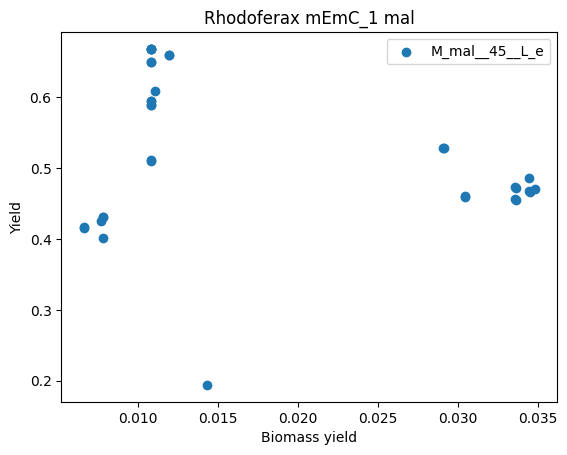

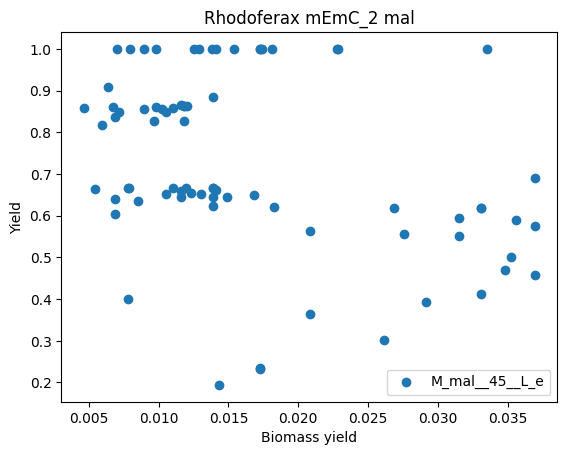

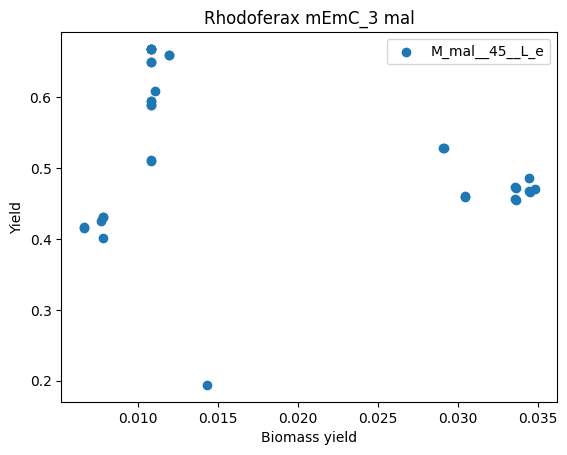

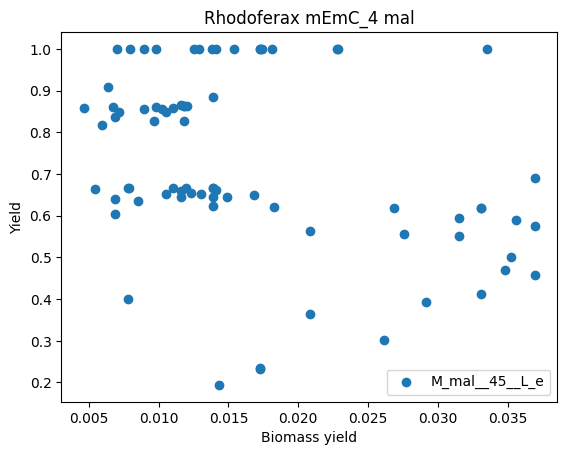

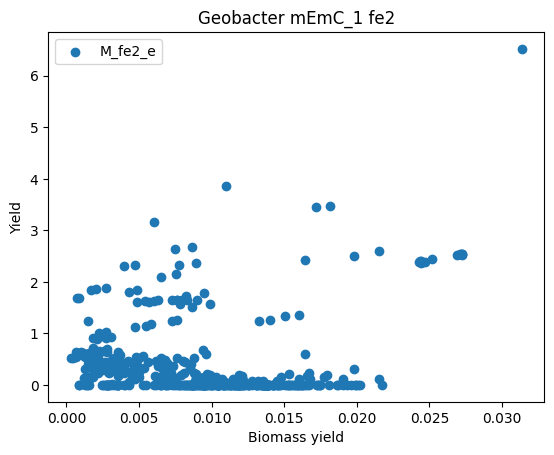

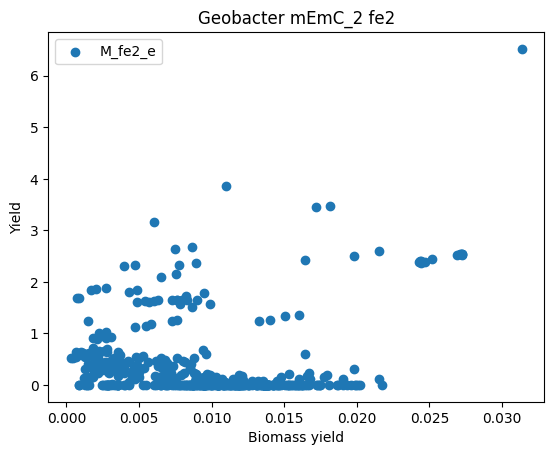

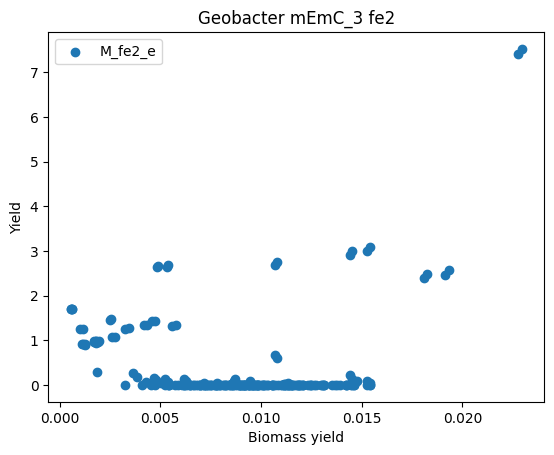

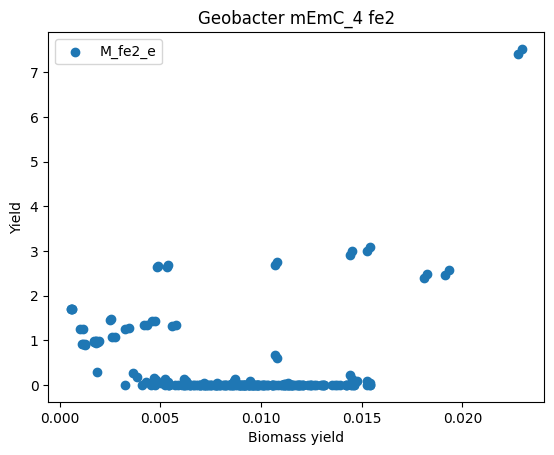

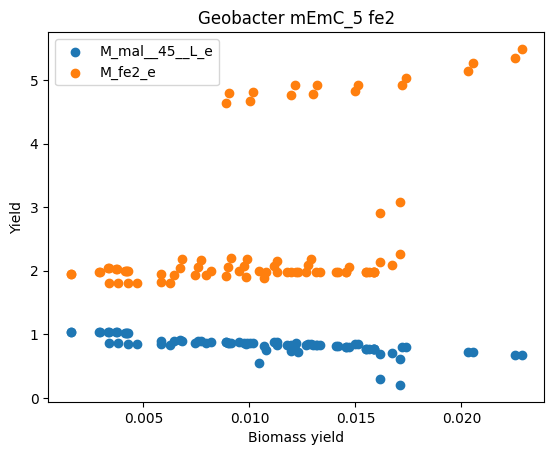

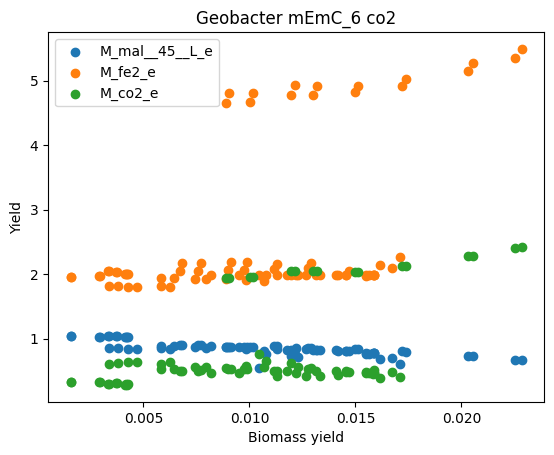

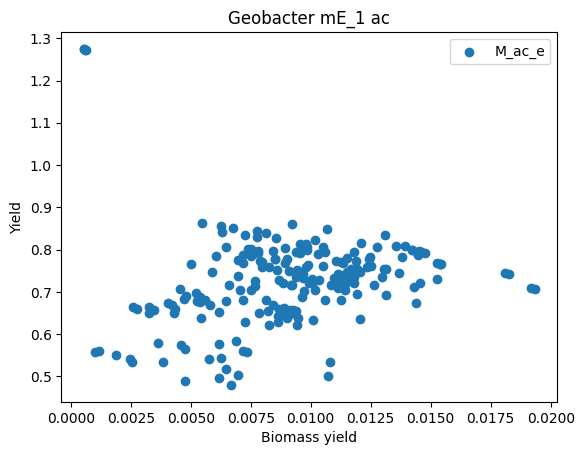

In [7]:
for model, dimes, in all_dimes.items():
    for dime_number, exchanges in dimes.items():
        c = c_sources[dime_number][model]
        sec = exchanges["secretion"]
        if not sec:
            continue

        ecms = filtered_ecms[dime_number][model]

        for met in sec:
            sec_yield = ecms[met]/ecms[c]
            bio_yield = ecms["objective"]/ecms[c]

            sec_name = re.sub(r"M_|__45__L|_e", "", met)
            plt.scatter(abs(bio_yield), abs(sec_yield))
            plt.xlabel("Biomass yield")
            plt.ylabel("Yield")
            plt.title(f"{model} {dime_number} {sec_name}")
        plt.legend(sec)
        plt.show()


In [8]:
filtered_ecms["mEmC_6"]['Rhodoferax']

,M_co2_e,M_fe2_e,M_glyclt_e,M_h2o_e,M_hom__45__L_e,M_mal__45__L_e,M_nh4_e,M_orot_e,M_pi_e,M_so4_e,M_succ_e,objective
13,-3.89302,-0.00003,0.00,108.0728,0.00000,-53.05469,-50.82357,19.95590,-0.9314,-0.25,18.42573,1.0
14,-3.89302,-0.00003,0.05,108.0478,0.00000,-53.07969,-50.82357,19.95590,-0.9314,-0.25,18.42573,1.0
28,-22.31874,-0.00003,0.05,181.7507,18.42573,-71.50541,-106.10075,38.38163,-0.9314,-0.25,0.00000,1.0
30,-22.31874,-0.00003,0.00,181.7757,18.42573,-71.48041,-106.10075,38.38163,-0.9314,-0.25,0.00000,1.0


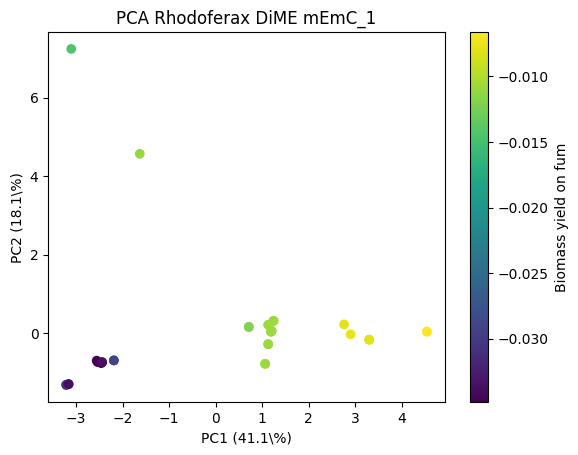

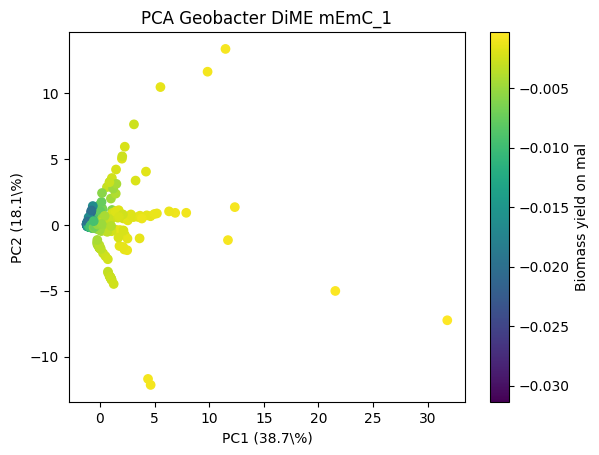

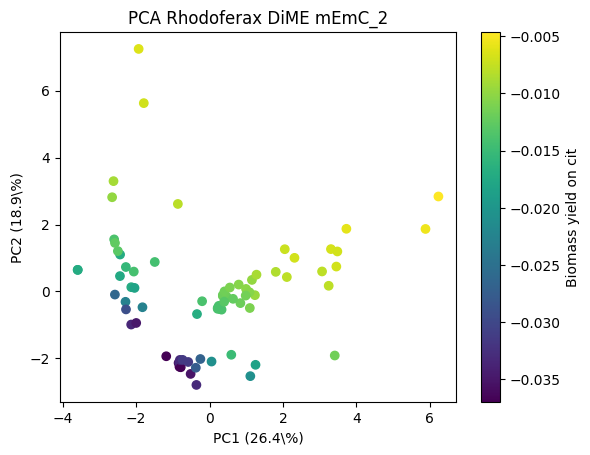

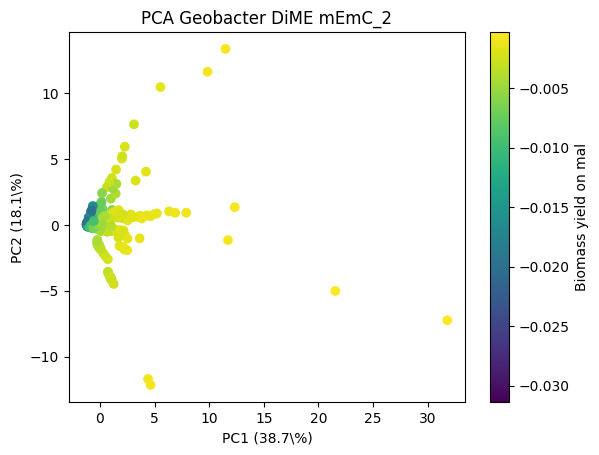

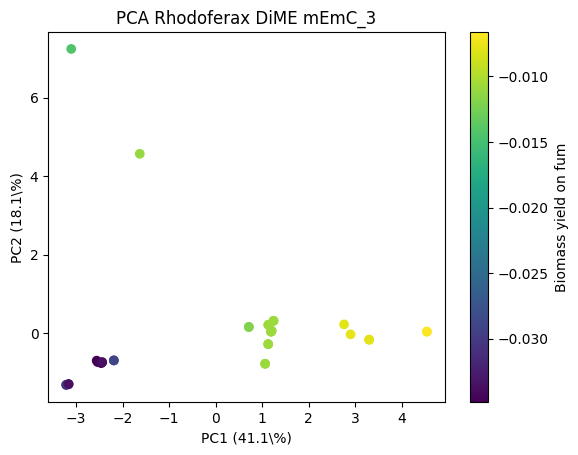

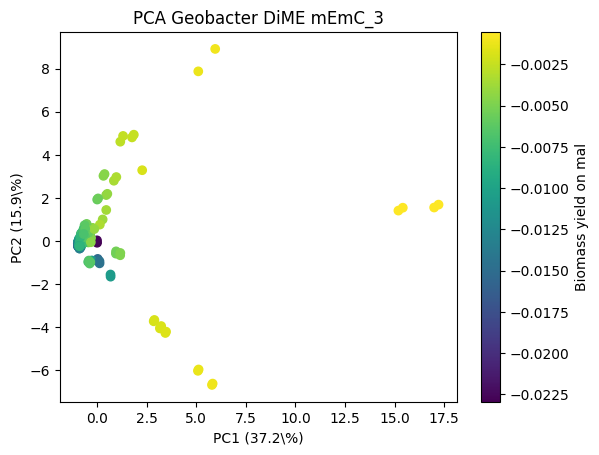

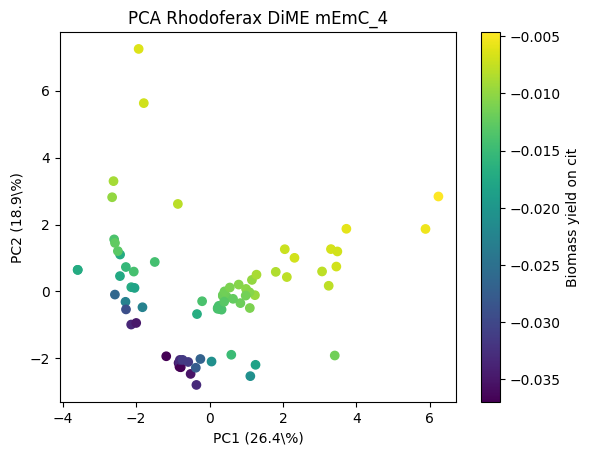

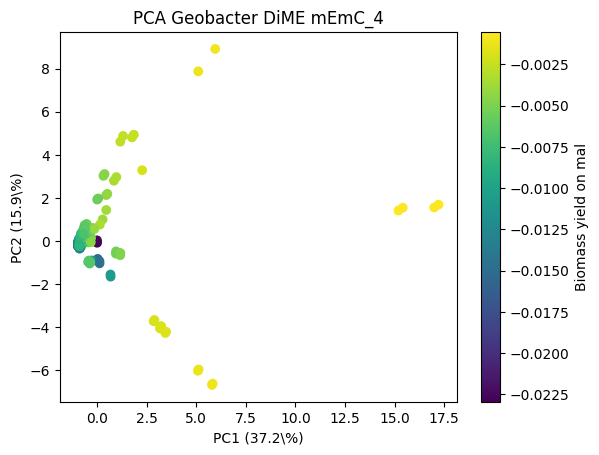

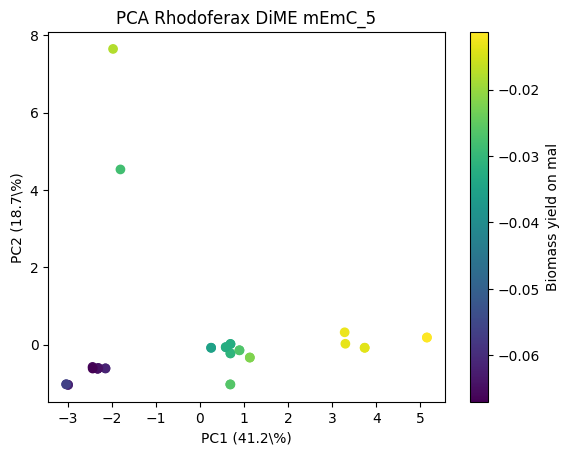

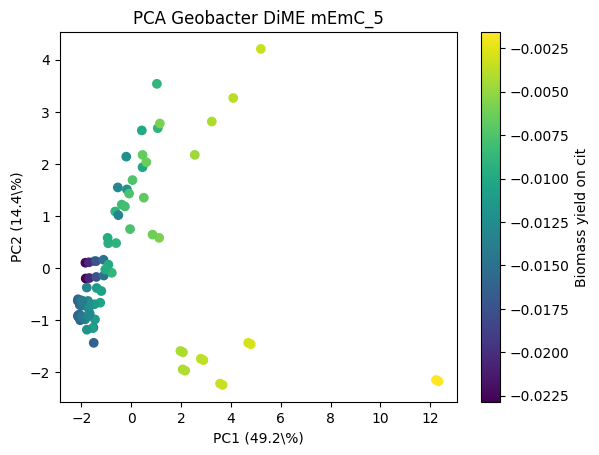

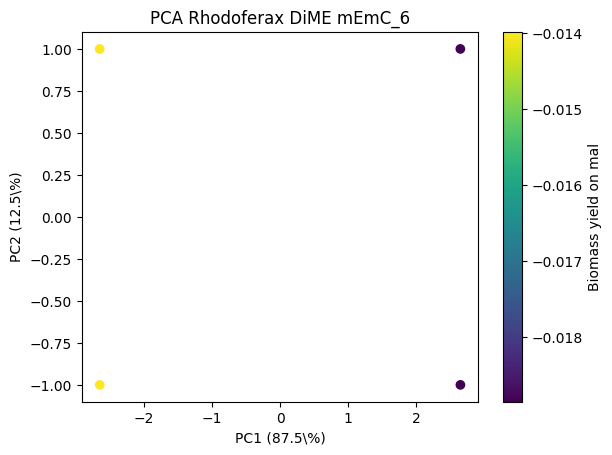

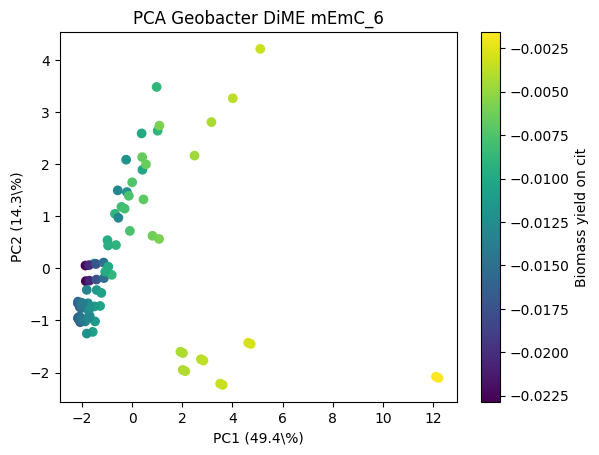

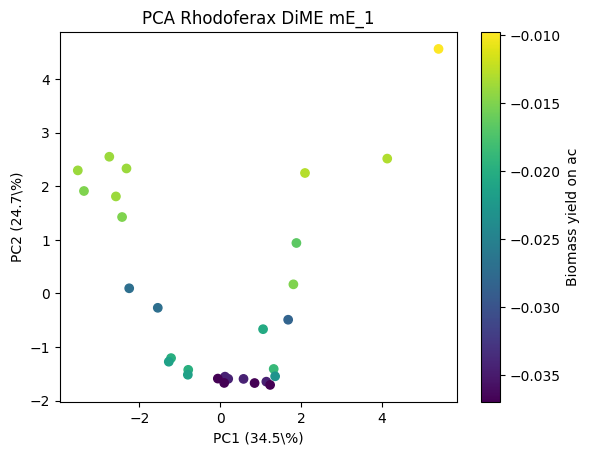

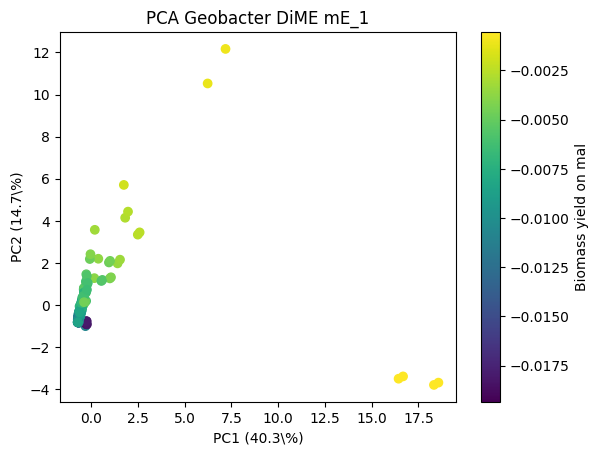

In [9]:
for dime, dime_ecms in filtered_ecms.items():
    for model, X in dime_ecms.items():

        # 2. Standardize (important!)
        X_scaled = StandardScaler().fit_transform(X)

        # 3. Apply PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        var = pca.explained_variance_ratio_

        plt.figure()
        yields_dime = X[bm_rxns[model]]/X[c_sources[dime][model]]
        sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=yields_dime)

        plt.xlabel(f"PC1 ({var[0]*100:.1f}\\%)")
        plt.ylabel(f"PC2 ({var[1]*100:.1f}\\%)")
        plt.title(f"PCA {model} DiME {dime}")

        met_name = re.sub(r"M_|__45__L|_e", "", c_sources[dime][model])
        plt.colorbar(sc, label=f"Biomass yield on {met_name}")
        plt.show()
